## Lab 3: Introduction to  Machine learning

## Theory:

Machine learning is a branch of Artificial Intelligence that focuses on developing models and algorithms that let computers learn from data without being explicitly programmed for every task. In simple words, ML teaches systems to think and understand like humans by learning from the data.

Machine Learning is mainly divided into three core types:

1. Supervised Learning: Trains models on labeled data to predict or classify new, unseen data.
2. Unsupervised Learning: Finds patterns or groups in unlabeled data, like clustering or dimensionality reduction.
3. Reinforcement Learning: Learns through trial and error to maximize rewards, ideal for decision-making tasks.

Importance:

1. Automation: Automates tasks like image recognition, speech processing, and decision-making.
2. Prediction: Helps forecast future outcomes such as weather, sales, and diseases.
3. Pattern Recognition: Finds hidden patterns in large datasets.
4. Better Decision Making: Provides data-driven insights.
5. Personalization: Provides customized recommendations in apps and websites.

### step 1: Data collection:

Collect data from databases, or user input

 ### 1.1: Llbrary import

In [5]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### 1.2 Data Generation

In [6]:

np.random.seed(42)

n_unique = 95

data = pd.DataFrame({
    'Weight': np.random.randint(80, 300, n_unique),
    'Diameter': np.random.uniform(5, 15, n_unique).round(2),
    'Sweetness': np.random.randint(1, 11, n_unique),
    'ColorScore': np.random.randint(1, 101, n_unique),
    'Firmness': np.random.randint(1, 11, n_unique),
    'Fruit': np.random.choice(
        ['Apple', 'Banana', 'Orange', 'Mango'],
        n_unique
    )
})

duplicates = data.sample(5, random_state=42)

dataset = pd.concat([data, duplicates], ignore_index=True)

feature_cols = [
    'Weight',
    'Diameter',
    'Sweetness',
    'ColorScore',
    'Firmness'
]

for _ in range(10):
    row = np.random.randint(0, 100)
    col = np.random.choice(feature_cols)
    dataset.loc[row, col] = np.nan

dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

print("Rows:", len(dataset))
print("Missing Values:", dataset.isna().sum().sum())
print("Duplicate Rows:", dataset.duplicated().sum())

dataset.to_csv("fruit_dataset.csv", index=False)

print(dataset.head())

Rows: 100
Missing Values: 10
Duplicate Rows: 3
   Weight  Diameter  Sweetness  ColorScore  Firmness   Fruit
0   133.0      9.04        4.0        36.0      10.0  Banana
1   214.0      7.03        5.0        54.0       7.0   Apple
2   278.0     11.48        6.0        48.0       7.0   Mango
3   254.0      7.02        7.0        85.0      10.0  Banana
4   269.0      9.39        3.0        63.0      10.0   Apple


Original Shape: (100, 6)
After Removing Duplicates: (97, 6)
Accuracy: 0.35

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.86      0.63         7
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         5
           3       0.50      0.25      0.33         4

    accuracy                           0.35        20
   macro avg       0.25      0.28      0.24        20
weighted avg       0.28      0.35      0.29        20



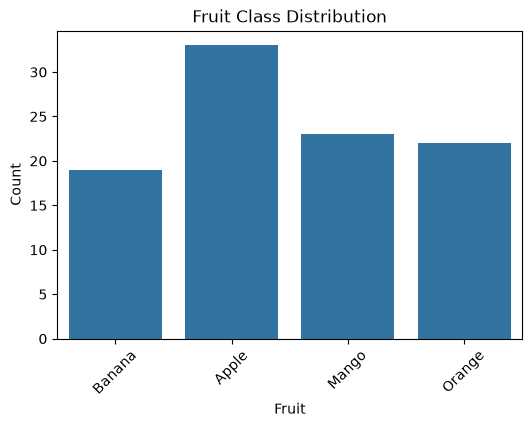

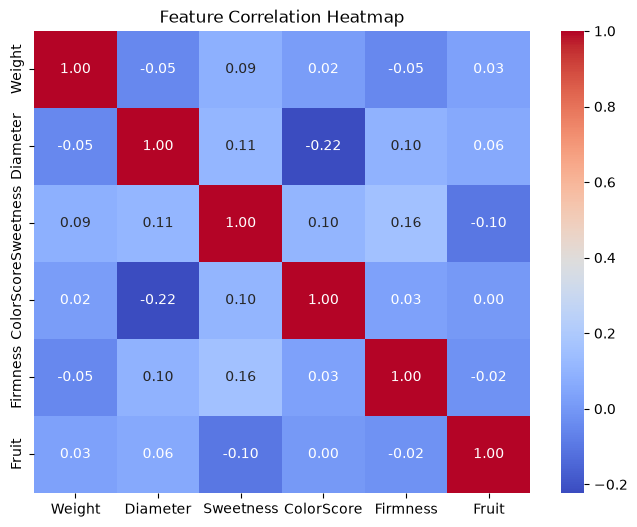

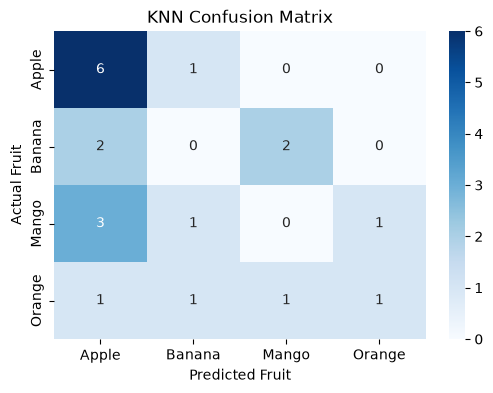

Predicted Fruit: Apple


In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


df = pd.read_csv("fruit_dataset.csv")

print("Original Shape:", df.shape)

df = df.drop_duplicates()

print("After Removing Duplicates:", df.shape)


feature_cols = [
    'Weight',
    'Diameter',
    'Sweetness',
    'ColorScore',
    'Firmness'
]


imputer = KNNImputer(n_neighbors=5)
df[feature_cols] = imputer.fit_transform(df[feature_cols])


encoder = LabelEncoder()
df['Fruit'] = encoder.fit_transform(df['Fruit'])


X = df[feature_cols]
y = df['Fruit']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)


y_pred = knn.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


plt.figure(figsize=(6,4))

sns.countplot(
    x=encoder.inverse_transform(df['Fruit'])
)

plt.title("Fruit Class Distribution")
plt.xlabel("Fruit")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()



plt.figure(figsize=(8,6))

sns.heatmap(
    df[feature_cols + ['Fruit']].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()



cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Fruit")
plt.ylabel("Actual Fruit")

plt.show()



weight = float(input("Enter Weight: "))
diameter = float(input("Enter Diameter: "))
sweetness = float(input("Enter Sweetness: "))
color_score = float(input("Enter Color Score: "))
firmness = float(input("Enter Firmness: "))


new_fruit = pd.DataFrame(
    [[weight, diameter, sweetness, color_score, firmness]],
    columns=feature_cols
)


new_fruit = scaler.transform(new_fruit)


prediction = knn.predict(new_fruit)


print(
    "Predicted Fruit:",
    encoder.inverse_transform(prediction)[0]
)

### Discussion:
This experiment has shown an entire process of machine learning, from the creation and preparation of the data to its preprocessing and finally to classification via KNN. Dealing with the duplicates, filling in the gaps with the help of KNNImputer, encoding the categorical labels, and scaling were done in the proper way. Thus, the data was ready for further modeling. All graphs have given us insight into the nature of the dataset and the model. This experiment gave practical skills regarding the process of creating a supervised learning model.


### Conclusion:
In this lab, we have been able to perform the complete process of machine learning, which includes data preprocessing, feature scaling, and classification using the KNN algorithm. This exercise has helped gain further knowledge about different aspects of machine learning like managing missing values, variable encoding, and assessment of the performance of a machine learning model through metrics and visualizations.